# 다음 영화 리뷰의 키워드 분석

1. 데이터 준비 (로딩)
2. 텍스트 전처리 (토큰화, 불용어 제거)
3. 빈도수 분석 (Counter)

* 시각화 1 : 수평 막대그래프
* 시각화 2 : 워드클라우드

In [2]:
# 데이터 준비
data_filename = './data/daum_movie_review.csv'

import pandas as pd
movie_df = pd.read_csv(data_filename)
# movie_df.head()
review_list = list(movie_df.review)
review_list[:10]

['돈 들인건 티가 나지만 보는 내내 하품만',
 '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
 '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
 '이 정도면 볼만하다고 할 수 있음!',
 '재미있다',
 '나는 재밌게 봄',
 '0.5점은 줄 수 없냐?',
 '헐..다 죽었어....나중에 앤트맨 보다가도 깜놀...',
 '충격 결말',
 '응집력']

In [16]:
# 텍스트 전처리
from konlpy.tag import Okt
tagger = Okt()

const_doc = " ".join(review_list)

pos_list = tagger.pos(const_doc)

my_tags = ['Noun', 'Verb']
my_tokens = [word for word, tag in pos_list if tag in my_tags]

my_stopwords = []
my_new_tokens =[token for token in my_tokens if token not in my_stopwords]

print(f'불용어 제거 후 토큰 수 : {len(my_new_tokens):,}')

my_tokens = my_new_tokens

불용어 제거 후 토큰 수 : 168,366


In [17]:
# 빈도수 분석
from collections import Counter
const_counter = Counter(my_tokens)

print(const_counter.most_common(20))

[('영화', 6691), ('연기', 1293), ('감동', 1223), ('생각', 1027), ('정말', 948), ('것', 927), ('이', 851), ('배우', 847), ('사람', 819), ('스토리', 815), ('더', 791), ('진짜', 781), ('잘', 776), ('하는', 770), ('눈물', 737), ('보고', 709), ('점', 692), ('최고', 682), ('좀', 671), ('재미', 641)]


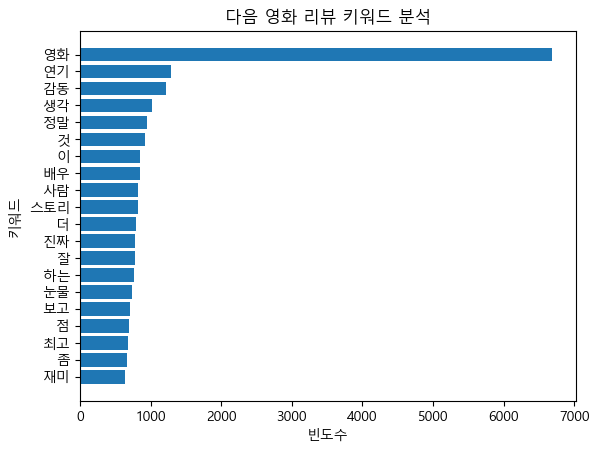

In [25]:
# 시각화 1 : 수평 막대그래프
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

most_freq_list = const_counter.most_common(20)

x_list = [word for word, count in most_freq_list]
y_list = [count for word, count in most_freq_list]

font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

plt.barh(x_list[::-1], y_list[::-1])

# 그래프 정보 추가 
plt.title('다음 영화 리뷰 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('키워드')

result_filename = './result/graph.jpg'
plt.savefig(result_filename)

# 화면에 출력
plt.show()


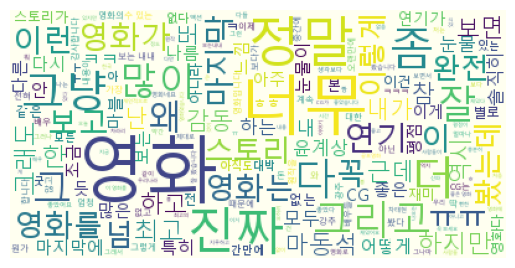

In [26]:
# 시각화 2 : 워드 클라우드
from wordcloud import WordCloud
import matplotlib.pyplot as plt

font_path = "c:/Windows/fonts/malgun.ttf"

const_wc = WordCloud(
    font_path = font_path,
    background_color='ivory'
)

const_wc = const_wc.generate(const_doc)

plt.imshow(const_wc)
plt.axis('off')
plt.show()

result_filename = './result/wordcloud.jpg'
const_wc.to_file(result_filename)